# Linear Regression Lab (One Variable) 


Flow of this lab:
1. Part 0: Dataset setup
2. Part 1: Data visualization
3. Part 2: Hypothesis function
4. Part 3: Cost function
5. Part 4: Gradient descent
6. Part 5: Learning process visualization
7. Part 6: Predictions on new data
8. Part 7: Model evaluation (R²)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Create output folder for saving plots
os.makedirs('outputs', exist_ok=True)

## Part 0: Dataset Setup
We prepare a simple dataset where area increases linearly with price.

In [4]:
print('=' * 70)
print('PART 0: LOADING AND EXPLORING THE DATASET')
print('=' * 70)

data = {
    'area': [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500],
    'price': [100, 150, 200, 250, 300, 350, 400, 450, 500, 550]
}

X = np.array(data['area']).reshape(-1, 1)
y = np.array(data['price']).reshape(-1, 1)

print(f'Number of training examples (m): {len(X)}')
print('Number of features (n): 1 (Area)')
print('\nFirst 5 examples:')
print('{:>15} | {:>15}'.format('Area (sq ft)', 'Price ($1000s)'))
print('-' * 35)
for i in range(5):
    print(f'{X[i][0]:>15.0f} | {y[i][0]:>15.0f}')

PART 0: LOADING AND EXPLORING THE DATASET
Number of training examples (m): 10
Number of features (n): 1 (Area)

First 5 examples:
   Area (sq ft) |  Price ($1000s)
-----------------------------------
           1000 |             100
           1500 |             150
           2000 |             200
           2500 |             250
           3000 |             300


## Part 1: Data Visualization
Scatter plot of area vs. price to see the linear trend.


PART 1: VISUALIZING THE DATA


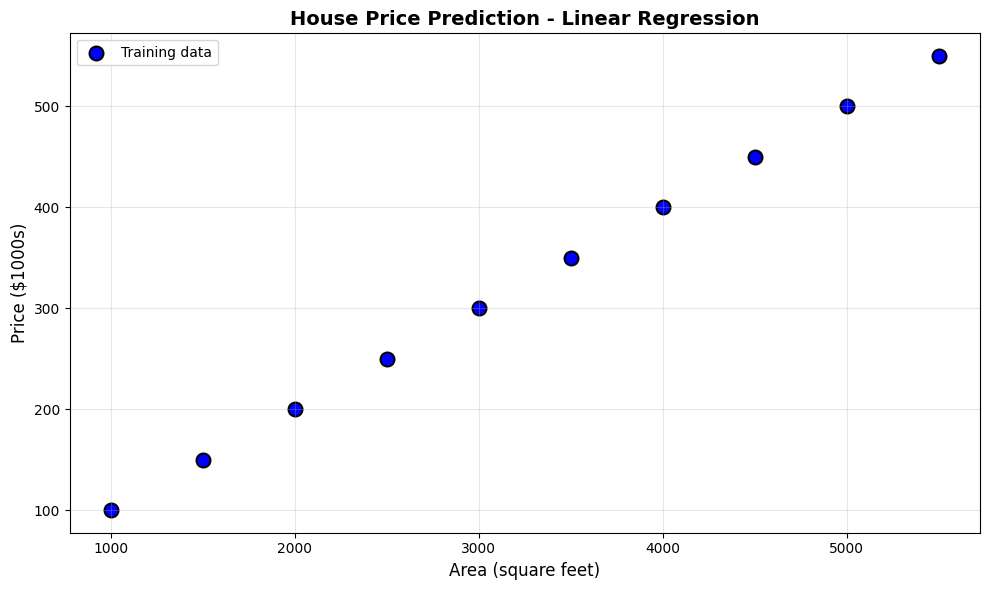

Visualization saved: outputs/exercise_01_data_visualization.png


In [6]:
print('\n' + '=' * 70)
print('PART 1: VISUALIZING THE DATA')
print('=' * 70)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', marker='o', s=100, label='Training data',
            edgecolors='black', linewidth=1.5)
plt.xlabel('Area (square feet)', fontsize=12)
plt.ylabel('Price ($1000s)', fontsize=12)
plt.title('House Price Prediction - Linear Regression', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/exercise_01_data_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualization saved: outputs/exercise_01_data_visualization.png')

## Part 2: Hypothesis Function
For one-variable linear regression:

$$h(x) = \theta_0 + \theta_1 x$$

This function predicts prices using current parameters.

In [9]:
def compute_hypothesis(X, theta_0, theta_1):
    """Compute predicted values using h(x) = theta_0 + theta_1 * x."""
    predictions = theta_0 + theta_1 * X
    return predictions

# Quick test
theta_0 = 0.0
theta_1 = 0.1
test_pred = compute_hypothesis(X[:2], theta_0, theta_1)
print('Initial parameters: theta_0=0.0, theta_1=0.1')
print('First 2 predictions:', test_pred.flatten())

Initial parameters: theta_0=0.0, theta_1=0.1
First 2 predictions: [100. 150.]


## Part 3: Cost Function (MSE Style Used in Gradient Descent)
We use:

$$J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)})-y^{(i)})^2$$

In [11]:
def compute_cost(X, y, theta_0, theta_1):
    """Compute cost J(theta_0, theta_1)."""
    m = len(X)
    predictions = compute_hypothesis(X, theta_0, theta_1)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

initial_cost = compute_cost(X, y, theta_0, theta_1)
print(f'Initial cost: {initial_cost:.4f}')

Initial cost: 0.0000


## Part 4: Gradient Descent
Update rules:

$$\theta_0 := \theta_0 - \alpha\cdot\frac{1}{m}\sum_{i=1}^{m}(h(x^{(i)})-y^{(i)})$$
$$\theta_1 := \theta_1 - \alpha\cdot\frac{1}{m}\sum_{i=1}^{m}(h(x^{(i)})-y^{(i)})x^{(i)}$$

We iterate these updates to reduce cost.

In [12]:
def gradient_descent(X, y, theta_0, theta_1, learning_rate=0.00001, iterations=1000):
    """Optimize theta_0 and theta_1 with batch gradient descent."""
    m = len(X)
    cost_history = []

    for iteration in range(iterations):
        predictions = compute_hypothesis(X, theta_0, theta_1)
        errors = predictions - y

        d_theta_0 = (1 / m) * np.sum(errors)
        d_theta_1 = (1 / m) * np.sum(errors * X)

        theta_0 = theta_0 - learning_rate * d_theta_0
        theta_1 = theta_1 - learning_rate * d_theta_1

        cost = compute_cost(X, y, theta_0, theta_1)
        cost_history.append(cost)

        if (iteration + 1) % 200 == 0:
            print(f'Iteration {iteration + 1:>4d} | Cost: {cost:>10.6f} | theta_0: {theta_0:>8.5f} | theta_1: {theta_1:>8.5f}')

    return theta_0, theta_1, cost_history

print('Running gradient descent...')
theta_0_new, theta_1_new, cost_history = gradient_descent(
    X, y, theta_0, theta_1, learning_rate=0.00001, iterations=1000
)

print('\nFinal parameters:')
print(f'theta_0 (intercept) = {theta_0_new:.6f}')
print(f'theta_1 (slope)     = {theta_1_new:.6f}')

Running gradient descent...
Iteration  200 | Cost:   0.000000 | theta_0:  0.00000 | theta_1:  0.10000
Iteration  400 | Cost:   0.000000 | theta_0:  0.00000 | theta_1:  0.10000
Iteration  600 | Cost:   0.000000 | theta_0:  0.00000 | theta_1:  0.10000
Iteration  800 | Cost:   0.000000 | theta_0:  0.00000 | theta_1:  0.10000
Iteration 1000 | Cost:   0.000000 | theta_0:  0.00000 | theta_1:  0.10000

Final parameters:
theta_0 (intercept) = 0.000000
theta_1 (slope)     = 0.100000


## Part 5: Visualize Learning Process
We plot:
1. Cost vs iteration (should decrease)
2. Final fitted line over the training data

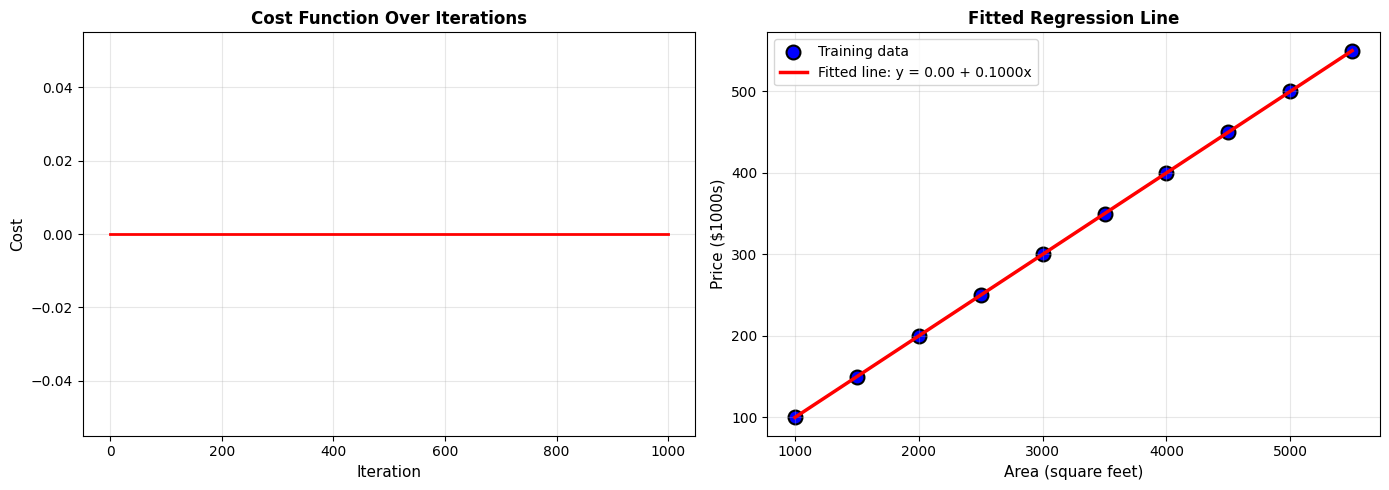

Learning visualization saved: outputs/exercise_02_learning_process.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_history, color='red', linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Cost', fontsize=11)
axes[0].set_title('Cost Function Over Iterations', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X, y, color='blue', marker='o', s=100,
                label='Training data', edgecolors='black', linewidth=1.5)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = compute_hypothesis(X_line, theta_0_new, theta_1_new)
axes[1].plot(X_line, y_line, color='red', linewidth=2.5,
             label=f'Fitted line: y = {theta_0_new:.2f} + {theta_1_new:.4f}x')
axes[1].set_xlabel('Area (square feet)', fontsize=11)
axes[1].set_ylabel('Price ($1000s)', fontsize=11)
axes[1].set_title('Fitted Regression Line', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/exercise_02_learning_process.png', dpi=100, bbox_inches='tight')
plt.show()
print('Learning visualization saved: outputs/exercise_02_learning_process.png')

## Part 6: Make Predictions on New Data
Use trained parameters with the same hypothesis formula.

In [16]:
def make_prediction(area, theta_0, theta_1):
    """Predict a single house price from area."""
    price = theta_0 + theta_1 * area
    return price

print(f'Learned model: Price = {theta_0_new:.4f} + {theta_1_new:.6f} * Area')
print('{:>15} | {:>25}'.format('Area (sq ft)', 'Predicted Price ($1000s)'))
print('-' * 45)

test_areas = [2200, 3500, 4200, 5800]
for area in test_areas:
    predicted_price = make_prediction(area, theta_0_new, theta_1_new)
    print(f'{area:>15} | {predicted_price:>25.2f}')

Learned model: Price = 0.0000 + 0.100000 * Area
   Area (sq ft) |  Predicted Price ($1000s)
---------------------------------------------
           2200 |                    220.00
           3500 |                    350.00
           4200 |                    420.00
           5800 |                    580.00


## Part 7: Model Evaluation (R²)
Coefficient of determination:

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

where:
- $SS_{res}=\sum (y-\hat{y})^2$
- $SS_{tot}=\sum (y-\bar{y})^2$

In [17]:
def calculate_r_squared(X, y, theta_0, theta_1):
    """Calculate R^2 score for the trained model."""
    predictions = compute_hypothesis(X, theta_0, theta_1)
    y_mean = np.mean(y)
    ss_res = np.sum((y - predictions) ** 2)
    ss_tot = np.sum((y - y_mean) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared

final_cost = compute_cost(X, y, theta_0_new, theta_1_new)
r_squared = calculate_r_squared(X, y, theta_0_new, theta_1_new)

print('Final model performance:')
print(f'Final Cost: {final_cost:.6f}')
print(f'R^2 Score : {r_squared:.6f}')

Final model performance:
Final Cost: 0.000000
R^2 Score : 1.000000


## Summary
You implemented and tested:
- Hypothesis function
- Cost function
- Gradient descent
- Prediction function
- R² evaluation

Next ideas:
- Try different learning rates
- Try different iterations
- Add noise and observe behavior
- Extend to multiple linear regression